In [1]:
using Pkg
Pkg.activate("calval")

  Activating project at `~/Documents/research/calval_tgrs/notebooks/calval`


In [2]:
using IceFloeTracker
using Images

In [6]:
using Random
function _get_random_color(seed)
    Random.seed!(seed)
    rand(RGB{N0f8})
end

"""
    view_seg_random(s::SegmentedImage)

Produce an RGB image with a random color for each unique segment in `s`.
"""
function view_seg_random(s)
    map(i -> (i == 0) ? RGB(0,0,0) : _get_random_color(i), labels_map(s))
end

view_seg_random

In [9]:
falsecolor_files[3]

"20140427.aqua.falsecolor.250m.tiff"

In [10]:
dataloc = "/Users/dmw/Documents/research/calval_tgrs/data/MODIS_JOG_example_case/"
falsecolor_files = filter(f -> f != ".DS_Store", readdir(joinpath(dataloc, "falsecolor")))
truecolor_files = replace.(falsecolor_files, ("falsecolor" => "truecolor"))
landmask_file = joinpath(dataloc, "landmask.tiff")
landmask_img = Gray.(load(landmask_file))
# for (fc_file, tc_file) in zip(falsecolor_files, truecolor_files)

fc_file = falsecolor_files[3]
tc_file = truecolor_files[3]
tc_img = RGB.(load(joinpath(dataloc, "truecolor", tc_file)))
fc_img = RGB.(load(joinpath(dataloc, "falsecolor", fc_file)))

segment = LopezAcosta2019.Segment()

@info "Processing image " * tc_file
@time begin
    segment_result = segment(tc_img, fc_img, landmask_img)
end

# save binary image
save(joinpath(dataloc, "LopezAcosta2019", "binary",
    replace(tc_file, ("truecolor.250m.tiff" => "binary_floes_v0.png")), 
    ), Gray.(binarize_segments(segment_result)))
    
# save colorized image
cview = view_seg_random(segment_result)
idx = binarize_segments(segment_result) .> 0
tc_img[idx] .= cview[idx]

save(joinpath(dataloc, "LopezAcosta2019", "colorized",
    replace(tc_file, ("truecolor.250m.tiff" => "colorized_floes_v0.png")), 
    ), tc_img)
# end

[ Info: Processing image 20140427.aqua.truecolor.250m.tiff
[ Info: building landmask and coastal buffer mask
[ Info: Building cloudmask
[ Info: Sharpening truecolor image
[ Info: Discriminating ice/water
[ Info: Segmenting floes part 1/3
[ Info: Segmenting floes part 2/3
[ Info: Building watersheds
[ Info: Segmenting floes part 3/3
[ Info: Done with k-means segmentation
[ Info: Labeling floes


472.269929 seconds (103.78 M allocations: 1.090 TiB, 20.04% gc time)


This version of IFT works right, and the new version has the error. So what gives? Where did the code change significantly?

Things to check:
- Preprocessing (main thing that was updated). Could be issue with adapt hist eq
- 

In [40]:
## LA2019 Pre-Processing
import IceFloeTracker.LopezAcosta2019: channelwise_adapthisteq

p = (diffusion_algorithm=PeronaMalikDiffusion(),
    adapthisteq_params=(nbins=256, rblocks=8, cblocks=8, clip=0.01),
     unsharp_mask_params=(smoothing_param=10, intensity=0.5))
fc_file = falsecolor_files[4]
tc_file = truecolor_files[4]

tc_img = RGB.(load(joinpath(dataloc, "truecolor", tc_file)))
fc_img = RGB.(load(joinpath(dataloc, "falsecolor", fc_file)))

truecolor_image = float64.(tc_img)
falsecolor_image = float64.(fc_img)
landmask = landmask_img .> 0
coastal_buffer_mask = dilate(landmask_img .> 0, strel_box((51, 51)))

@info "Building cloudmask"
# TODO: Make sure tests aren't over-sensitive to roundoff errors for Float32 vs Float64
cloudmask = create_cloudmask(falsecolor_image)

# 2. Intermediate images
fc_masked = apply_landmask(falsecolor_image, coastal_buffer_mask)

@info "Preprocessing truecolor image"
# nonlinear diffusion
apply_landmask!(truecolor_image, landmask)
sharpened_truecolor_image = nonlinear_diffusion(
    truecolor_image, p.diffusion_algorithm
)

# changed to AdaptiveEqualization directly, could be an issue with channelwise adapthisteq
sharpened_truecolor_image .= adjust_histogram(Gray.(sharpened_truecolor_image), AdaptiveEqualization(
    nbins=p.adapthisteq_params.nbins,
    rblocks=p.adapthisteq_params.rblocks,
    cblocks=p.adapthisteq_params.cblocks,
    clip=p.adapthisteq_params.clip
))

sharpened_grayscale_image = unsharp_mask(
    Gray.(sharpened_truecolor_image),
    p.unsharp_mask_params.smoothing_param,
    p.unsharp_mask_params.intensity,
)
apply_landmask!(sharpened_grayscale_image, coastal_buffer_mask)

[ Info: Building cloudmask
[ Info: Preprocessing truecolor image


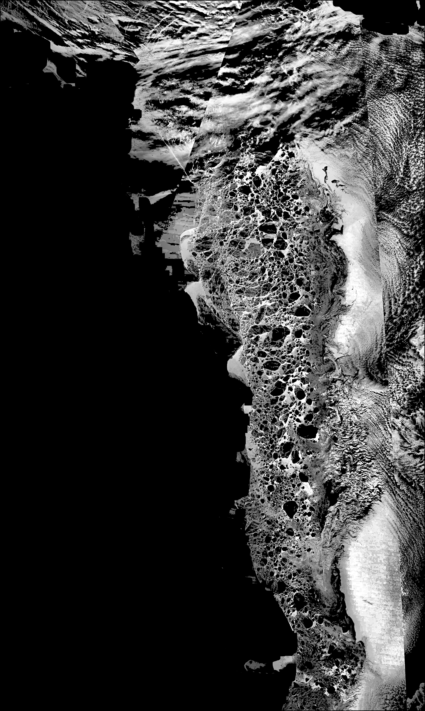

In [41]:
ice_water_discrim = LopezAcosta2019.discriminate_ice_water(
    sharpened_grayscale_image, fc_masked, coastal_buffer_mask, cloudmask
)

In [42]:
function clean_binary_floes(bw_img; min_opening_area=50)
    img_opened = area_opening(bw_img; min_area=min_opening_area) |> hbreak
    img_filled = branch(img_opened) |> bridge |> fill_holes
    diff_matrix = img_opened .!= img_filled
    return bw_img .|| diff_matrix
end

clean_binary_floes (generic function with 1 method)

In [43]:
kmeans_result = kmeans_binarization(
            ice_water_discrim,
            fc_masked;
            k=4,
            maxiter=50,
            random_seed=45,
            cluster_selection_algorithm=IceDetectionLopezAcosta2019()
            ) |> clean_binary_floes;

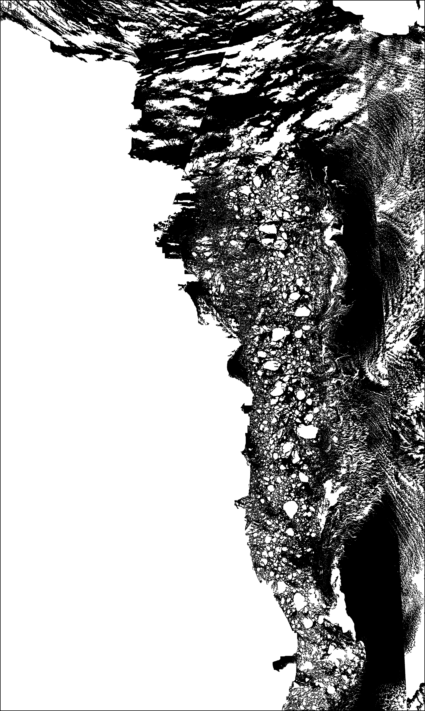

In [44]:
Gray.(kmeans_result)

In [45]:
segB = LopezAcosta2019.segmentation_B(sharpened_grayscale_image, cloudmask, kmeans_result);

In [49]:
watersheds_segB = [
        LopezAcosta2019.watershed_ice_floes(segB.not_ice_bit), LopezAcosta2019.watershed_ice_floes(segB.ice_intersect)
    ]
watersheds_segB_product = LopezAcosta2019.watershed_product(watersheds_segB...)

5680×3392 BitMatrix:
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     

In [51]:
segF = LopezAcosta2019.segmentation_F(
        segB.not_ice,
        segB.ice_intersect,
        watersheds_segB_product,
        fc_masked,
        cloudmask,
        coastal_buffer_mask,
    );

[ Info: Done with k-means segmentation


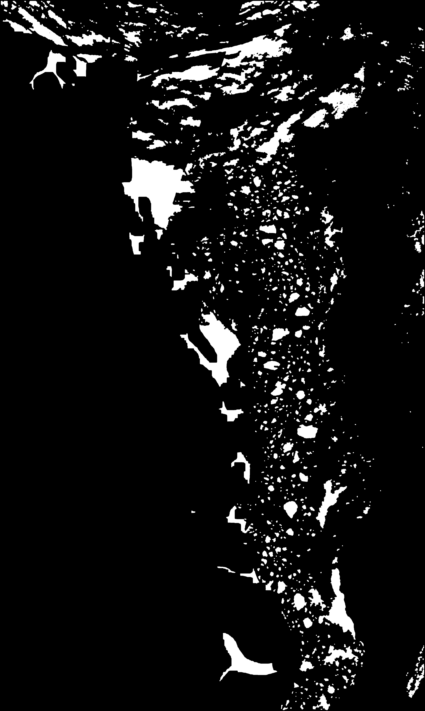

In [52]:
# to do : figure out how the persist function works, and run the LA2019 method in 
# vscode exporting the intermediates. Where does the information disappear?
Gray.(segF)